In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from joblib import Parallel, delayed
import os
import numpy as np
import matplotlib.pyplot as plt
import concurrent.futures
import time
from tqdm import tqdm


In [4]:
def gr_L_keni(T_l, A_l, tol=1e-16):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))
    if max_err > 1e-6:
        raise RuntimeError(
            f"Self-consistency violated: max |Δ| = {max_err:e}"
        )

    return gL

def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))
    if max_err > check_tol:
        mag = np.abs(eigvals)
        print("Sorted |eigvals|:", np.sort(mag))
        raise RuntimeError(
            fr"Self-consistency violated: max |Δ| = {max_err}"
        )

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD_old(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):

    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)


    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    A_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
 
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == xshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁
        if i < xshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T

    A_DD = np.block(A_DD)

    G_DD_r = np.linalg.inv(A_DD)
    G_RL = G_DD_r[-d_device:, :d_device]
    return G_RL , Sigma_R, Sigma_L

def Gr_DD(H_DD, H_l, H_r, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):
    d_device = H_DD[0][0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    A_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H_q_i = H_DD[i][i]

        # 加上自能
        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == xshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁 (非对角项，直接从 H_DD 中提取对应的块)
        if i < xshumu-1:
            A_DD[i][i+1] = -H_DD[i][i+1] 
        if i > 0:
            A_DD[i][i-1] = -H_DD[i][i-1]  

    A_DD_matrix = np.block(A_DD)

    G_DD_r = np.linalg.inv(A_DD_matrix)
    G_RL = G_DD_r[-d_device:, :d_device]
    return G_RL, Sigma_R, Sigma_L

def Gr_DD_2_old(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):
    N = xshumu
    
    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    V = T_21
    V_dagger = V.conj().T
    
    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N, d_device, d_device), dtype=complex)
    
    # 1. 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_q_list[0] - Sigma_L)
    
    # 2. 中间层：通过 Dyson 方程，把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N-1):
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_q_list[n] - Sigma_eff_L)
        
    # 3. 第 N-1 层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    Sigma_eff_L_last = V_dagger @ gL[N-2] @ V
    gL[N-1] = np.linalg.inv(EI_device - H_q_list[N-1] - Sigma_eff_L_last - Sigma_R)
    
    # 4. 回溯提取透射矩阵 G_RL (即 G_{N-1, 0}，波函数从左侧 0 传播到右侧 N-1)
    G_RL = gL[N-1].copy()
    for n in range(N-2, -1, -1):
        G_RL = G_RL @ V_dagger @ gL[n]

    # 直接返回这三个计算电导的必需品，G_RL 的维度是 160x160
    return G_RL, Sigma_R, Sigma_L

def Gr_DD_2(H_DD, H_l, H_r, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):
    """
    修改后的递归格林函数计算 (RGF方法)
    :param H_DD: 传入 H_center[1]，即包含所有在位能和层间跃迁的二维列表
    """
    N = xshumu
    
    # 直接从 H_DD 获取 device 维度
    d_device = H_DD[0][0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N, d_device, d_device), dtype=complex)
    
    # 1. 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_DD[0][0] - Sigma_L)
    
    # 2. 中间层：通过 Dyson 方程，把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N-1):
        # 动态提取两层之间的跃迁矩阵 (支持 SSH 和无序)
        V = H_DD[n-1][n]          # 从 n-1 跃迁到 n
        V_dagger = H_DD[n][n-1]   # 从 n 跃迁回 n-1
        
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_DD[n][n] - Sigma_eff_L)
        
    # 3. 第 N-1 层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    V_last = H_DD[N-2][N-1]
    V_dagger_last = H_DD[N-1][N-2]
    Sigma_eff_L_last = V_dagger_last @ gL[N-2] @ V_last
    gL[N-1] = np.linalg.inv(EI_device - H_DD[N-1][N-1] - Sigma_eff_L_last - Sigma_R)
    
    # 4. 回溯提取透射矩阵 G_RL (即 G_{N-1, 0}，波函数从左侧 0 传播到右侧 N-1)
    G_RL = gL[N-1].copy()
    for n in range(N-2, -1, -1):
        # 回溯时使用的跃迁矩阵是从 n+1 回到 n (对应原代码的 V_dagger)
        V_dagger_back = H_DD[n+1][n]  
        G_RL = G_RL @ V_dagger_back @ gL[n]

    return G_RL, Sigma_R, Sigma_L


In [ ]:
#参数
def H_onstie(weineng, mu, Delta, chaodaojiao):
    return np.array([
    [weineng-mu, 0, 0, Delta*np.exp(1j*chaodaojiao)],
    [0, weineng-mu, -Delta*np.exp(1j*chaodaojiao), 0],
    [0, -Delta*np.exp(-1j*chaodaojiao), -weineng+mu, 0],
    [Delta*np.exp(-1j*chaodaojiao), 0, 0, -weineng+mu] ], dtype=complex) 

def H_hop(t):
    return np.array([
    [-t, 0, 0, 0],
    [0, -t, 0, 0],
    [0, 0, t, 0],
    [0, 0, 0, t] ], dtype=complex) 

def H_old(H_q_list, T_21_list, xshumu):
    d_device = H_q_list[0].shape[0]            
    Z = np.zeros((d_device, d_device), dtype=complex)
    H_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]
    
    for i in range(xshumu):
        H_DD[i][i] = H_q_list[i]  
        
        if i < xshumu - 1:
            H_DD[i][i+1] = T_21_list[i]
            
        if i > 0:
            H_DD[i][i-1] = T_21_list[i-1].conj().T 
    
    H_DD_1=np.block(H_DD)
    return H_DD_1,H_DD

def H(H_q_list, T_21_list, xshumu):
    """
    使用 NumPy 切片构建块状三对角哈密顿量矩阵。
    """
    d_device = H_q_list[0].shape[0]
    # 计算最终大矩阵的维度：区块数量 * 单个区块维度
    total_dim = xshumu * d_device
    
    # 预分配整个哈密顿量矩阵（默认用 0 填充）
    H_full = np.zeros((total_dim, total_dim), dtype=complex)
    
    for i in range(xshumu):
        # 计算当前区块在主矩阵中的行/列索引范围
        start_idx = i * d_device
        end_idx = (i + 1) * d_device
        
        # 1. 填充对角块 (On-site 势能和超导配对)
        H_full[start_idx:end_idx, start_idx:end_idx] = H_q_list[i]
        
        # 2. 填充非对角块 (Hopping 项)
        if i < xshumu - 1:
            next_start = (i + 1) * d_device
            next_end = (i + 2) * d_device
            
            # i 到 i+1 的跃迁（主对角线右侧）
            H_full[start_idx:end_idx, next_start:next_end] = T_21_list[i]
            
            # i+1 到 i 的跃迁（主对角线左侧，等于其共轭转置）
            H_full[next_start:next_end, start_idx:end_idx] = T_21_list[i].conj().T

    # 返回主矩阵，并将不需要的列表变量替换为 None 释放内存
    return H_full, None

#一般
mu_l=0
mu_r=0
t=-1
xshumu_L=233
xshumu_R=233
Delta=0.1*t

#无序
W_disorder = 3
random_potentials = np.random.uniform(-W_disorder/2, W_disorder/2, xshumu_R+xshumu_L)

#准周期
weineng_a=-1.1*t
weineng_b=0.7*t
pinglv=89/144
#pinglv=144 / 233

jiaodu_L=0.9*np.pi
weineng_L_list=[]
for i in range(1,xshumu_L+1):
    X_j = np.sign(np.cos(2*np.pi*i*pinglv+jiaodu_L)-np.cos(np.pi*pinglv))
    if X_j>0:
        weineng_L_list.append(weineng_a)
    else:
        weineng_L_list.append(weineng_b)

jiaodu_R=0.45*np.pi
weineng_R_list=[]
for i in range(1,xshumu_R+1):
    X_j = np.sign(np.cos(2*np.pi*i*pinglv+jiaodu_R)-np.cos(np.pi*pinglv))
    if X_j>0:
        weineng_R_list.append(weineng_a)
    else:
        weineng_R_list.append(weineng_b)


#左边
T_l_list = []
for i in range(xshumu_L-1): 
    T_l_list.append(H_hop(t))

chaodaojiao_L = np.pi*0.2
H_l_list=[]
for i in range(xshumu_L):
    H_l_list.append(H_onstie(weineng_L_list[i], mu_l, Delta, chaodaojiao_L))

#右边
T_r_list = []
for i in range(xshumu_R-1): 
    T_r_list.append(H_hop(t))

chaodaojiao_R = np.pi*0
H_r_list=[]
for i in range(xshumu_R):
    H_r_list.append(H_onstie(weineng_R_list[i], mu_r, Delta, chaodaojiao_R))

#中间
T_L_to_R=[H_hop(t*0.6)]

#输出矩阵
H_q_list=H_l_list+H_r_list
T_21_list=T_l_list + T_L_to_R + T_r_list
H_center=H(H_q_list, T_21_list, xshumu_R+xshumu_L)

#解
H_matrix = H_center[0]
eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)

def get_spectrum_by_phase(chaodaojiao_L_val):
    """
    输入左侧超导相位，返回哈密顿量矩阵及其特征值。
    注意：此函数依赖于外部已计算好的 weineng_L_list, H_r_list, T_21_list 等常量。
    """
    # 重新计算左边的 On-site 矩阵列表
    H_l_list_new = []
    for i in range(xshumu_L):
        H_l_list_new.append(H_onstie(weineng_L_list[i], mu_l, Delta, chaodaojiao_L_val))
    
    # 组合新的总 On-site 列表 (右边保持不变)
    H_q_list_new = H_l_list_new + H_r_list
    
    # 使用你改进后的 H 函数切片生成总矩阵
    # T_21_list 不随相位变化，直接使用全局变量
    H_center_new = H(H_q_list_new, T_21_list, xshumu_R + xshumu_L)
    H_matrix_new = H_center_new[0]
    
    # 求解特征值 
    # (如果不需要特征向量，建议换成 np.linalg.eigvalsh(H_matrix_new) 以节省时间)
    eigenvalues_new, _ = np.linalg.eigh(H_matrix_new)
    
    return H_matrix_new, eigenvalues_new




In [23]:

# ---------------------------------------------------------
# 2. 多线程循环计算
# ---------------------------------------------------------
# 定义相位的取值范围：0 到 2*pi，取 20 个点
phase_array = np.linspace(0, 2 * np.pi, 20)

# 用于存储所有散点数据的平铺列表 (散点图不需要排序)
all_phases = []
all_energies = []

# 定义供线程调用的包装函数
def compute_task(phi):
    # 调用获取特征值的函数 (请确保 get_spectrum_by_phase 已定义)
    _, eigvals = get_spectrum_by_phase(phi)
    return phi, eigvals

print("启动 10 线程并发计算...")
start_time = time.time()

# 使用 ThreadPoolExecutor 管理 10 个线程
with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    # 提交所有任务
    future_to_phi = {executor.submit(compute_task, phi): phi for phi in phase_array}
    
    # 使用 tqdm 包装，显示进度条
    for future in tqdm(concurrent.futures.as_completed(future_to_phi), total=len(phase_array), desc="对角化进度", ncols=80):
        phi_val = future_to_phi[future]
        try:
            phi_res, evals = future.result()
            
            # 铺平数据：将当前的相位值复制 len(evals) 次，和特征值一一对应
            all_phases.extend([phi_res] * len(evals))
            all_energies.extend(evals)
            
        except Exception as exc:
            tqdm.write(f"phi = {phi_val:.3f} 产生异常: {exc}")

end_time = time.time()
print(f"全部计算完成！总耗时: {end_time - start_time:.2f} 秒")


启动 10 线程并发计算...


对角化进度: 100%|███████████████████████████████| 20/20 [01:35<00:00,  4.80s/it]

全部计算完成！总耗时: 95.95 秒


正在绘图...


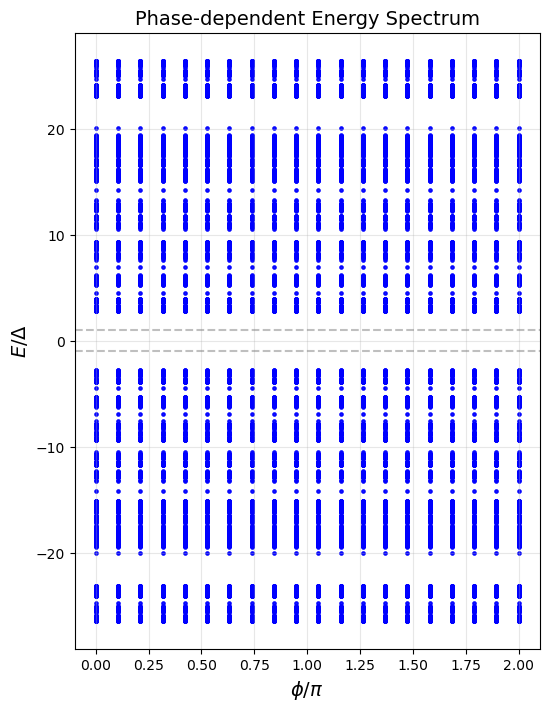

In [25]:
# ---------------------------------------------------------
# 3. 整理数据并画图 (散点图格式)
# ---------------------------------------------------------
print("正在绘图...")

# 将列表转换为 numpy 数组，并进行归一化处理以便对比论文
all_phases_arr = np.array(all_phases) / np.pi
# 注意：确保 Delta 在全局变量中已经定义（你前面的代码中 Delta = 0.1 * t）
all_energies_arr = np.array(all_energies) / Delta 

# 绘图
plt.figure(figsize=(6, 8))
plt.scatter(all_phases_arr, all_energies_arr, s=5, c='blue', alpha=0.7)

# 根据需要放开范围限制观察带隙内部的 Andreev 束缚态
# plt.ylim(-5, 5)
# plt.xlim(0, 2)

# 设置标签和标题
plt.xlabel(r'$\phi / \pi$', fontsize=14)
plt.ylabel(r'$E / \Delta$', fontsize=14)
plt.title('Phase-dependent Energy Spectrum', fontsize=14)

# 添加参考线：超导能隙边界 +-1
plt.axhline(1, color='gray', linestyle='--', alpha=0.5)
plt.axhline(-1, color='gray', linestyle='--', alpha=0.5)

plt.grid(True, alpha=0.3)
plt.show()